In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [59]:
 df = pd.read_csv("/content/globalAirQuality.csv")

df.head()

,timestamp,country,city,latitude,longitude,pm25,pm10,no2,so2,o3,co,aqi,temperature,humidity,wind_speed
0,2025-11-04 18:25:17.554219,US,New York,40.713,-74.006,50.295,108.938,27.998,6.539,52.568,1.096,108,18.504,70.168,3.725
1,2025-11-04 19:25:17.554219,US,New York,40.713,-74.006,32.083,63.043,36.120,4.021,43.536,1.075,90,5.838,80.088,8.969
2,2025-11-04 20:25:17.554219,US,New York,40.713,-74.006,42.250,82.553,26.935,9.538,23.320,0.977,84,31.833,62.783,9.650
3,2025-11-04 21:25:17.554219,US,New York,40.713,-74.006,30.403,79.951,63.536,7.609,31.369,0.230,158,23.140,89.153,8.956
4,2025-11-04 22:25:17.554219,US,New York,40.713,-74.006,21.083,66.423,38.997,6.919,45.615,1.085,97,13.632,76.499,4.017


In [60]:
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   timestamp    18000 non-null  object 
 1   country      18000 non-null  object 
 2   city         18000 non-null  object 
 3   latitude     18000 non-null  float64
 4   longitude    18000 non-null  float64
 5   pm25         18000 non-null  float64
 6   pm10         18000 non-null  float64
 7   no2          18000 non-null  float64
 8   so2          18000 non-null  float64
 9   o3           18000 non-null  float64
 10  co           18000 non-null  float64
 11  aqi          18000 non-null  int64  
 12  temperature  18000 non-null  float64
 13  humidity     18000 non-null  float64
 14  wind_speed   18000 non-null  float64
dtypes: float64(11), int64(1), object(3)
memory usage: 2.1+ MB


In [61]:
df = df[['pm25', 'pm10','so2','no2', 'o3', 'aqi','temperature','humidity']]
df.head()



,pm25,pm10,so2,no2,o3,aqi,temperature,humidity
0,50.295,108.938,6.539,27.998,52.568,108,18.504,70.168
1,32.083,63.043,4.021,36.120,43.536,90,5.838,80.088
2,42.250,82.553,9.538,26.935,23.320,84,31.833,62.783
3,30.403,79.951,7.609,63.536,31.369,158,23.140,89.153
4,21.083,66.423,6.919,38.997,45.615,97,13.632,76.499


In [62]:
df.isnull().sum()
df = df.dropna()
df.info()
X = df[['pm25', 'pm10','so2','no2' ,'o3','temperature','humidity']]
y = df['aqi']



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   pm25         18000 non-null  float64
 1   pm10         18000 non-null  float64
 2   so2          18000 non-null  float64
 3   no2          18000 non-null  float64
 4   o3           18000 non-null  float64
 5   aqi          18000 non-null  int64  
 6   temperature  18000 non-null  float64
 7   humidity     18000 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 1.1 MB


In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [64]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)


In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred_lr))

mse = mean_squared_error(y_test, y_pred_lr)
print("MSE:", mse)

rmse = np.sqrt(mse)
print("RMSE:", rmse)

print("R2 Score:", r2_score(y_test, y_pred_lr))


MAE: 11.983554333444117
MSE: 221.62763728823893
RMSE: 14.887163507137245
R2 Score: 0.6262636925780811


In [66]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1)).ravel()

In [67]:

from sklearn.svm import SVR

svr_model = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)

svr_model.fit(X_train_scaled, y_train_scaled)

SVR(C=100)

In [68]:
y_pred_svr_scaled = svr_model.predict(X_test_scaled)
y_pred_svr = scaler_y.inverse_transform(y_pred_svr_scaled.reshape(-1,1))

In [69]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("SVR Performance")

mae = mean_absolute_error(y_test, y_pred_svr)
mse = mean_squared_error(y_test, y_pred_svr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_svr)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

SVR Performance
MAE: 1.796693481909636
MSE: 5.067056492398347
RMSE: 2.251012326132033
R2 Score: 0.9914552940863404


In [70]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [71]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))


MAE: 0.07914722222222238
RMSE: 0.561025969888105
R² Score: 0.9994692288556238


In [72]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "SVR", "Random Forest"],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_svr),
        r2_score(y_test, y_pred)
    ]
})

results

,Model,R2 Score
0,Linear Regression,0.626264
1,SVR,0.991455
2,Random Forest,0.999469


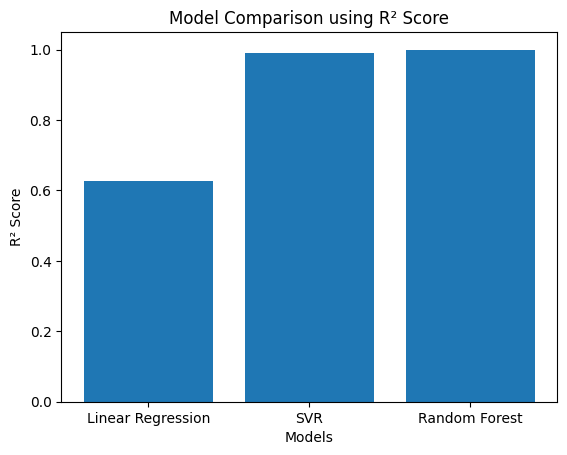

In [73]:
models = ['Linear Regression', 'SVR', 'Random Forest']
r2_scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_svr),
    r2_score(y_test, y_pred)
]

plt.figure()
plt.bar(models, r2_scores)
plt.xlabel('Models')
plt.ylabel('R² Score')
plt.title('Model Comparison using R² Score')
plt.show()

In [74]:
def aqi_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"

def early_warning(aqi):
    if aqi > 300:
        return "Emergency action required!"
    elif aqi > 200:
        return "Pollution increasing rapidly"
    elif aqi > 100:
        return "Sensitive groups should be careful"
    else:
        return "Air quality under control"


def health_advisory(aqi):
    if aqi > 300:
        return "Health Advisory: Avoid outdoor activity. High health risk."
    elif aqi > 200:
        return "Health Advisory: Wear masks and limit outdoor exposure."
    elif aqi > 100:
        return "Health Advisory: Children & elderly should be cautious."
    else:
        return "Health Advisory: Safe for outdoor activities."


In [75]:
from sklearn.ensemble import VotingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import r2_score
from sklearn import set_config

# Enable the visual diagram display
set_config(display='diagram')

lr_pipeline = make_pipeline(StandardScaler(), LinearRegression())
svr_pipeline = make_pipeline(StandardScaler(), SVR(kernel='rbf'))

ensemble_model = VotingRegressor(
    estimators=[
        ('lr', lr_pipeline),
        ('svr', svr_pipeline),
        ('rf', model)
    ]
)

ensemble_model.fit(X_train, y_train)

y_pred_ensemble = ensemble_model.predict(X_test)
print(f"Ensemble R2 Score: {r2_score(y_test, y_pred_ensemble):.4f}")

ensemble_model

Ensemble R2 Score: 0.9435


VotingRegressor(estimators=[('lr',
                             Pipeline(steps=[('standardscaler',
                                              StandardScaler()),
                                             ('linearregression',
                                              LinearRegression())])),
                            ('svr',
                             Pipeline(steps=[('standardscaler',
                                              StandardScaler()),
                                             ('svr', SVR())])),
                            ('rf', RandomForestRegressor(random_state=42))])

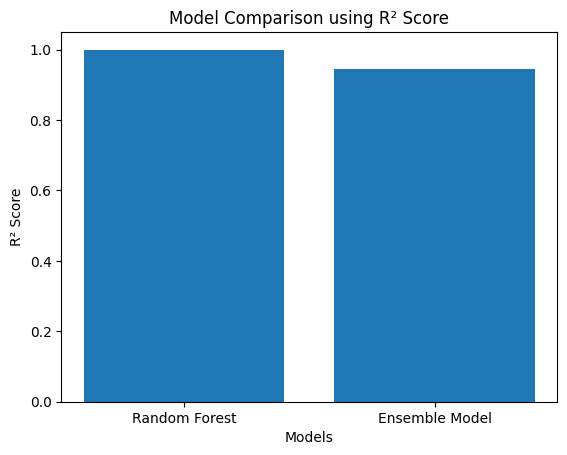

In [76]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Predictions
y_pred_rf = model.predict(X_test)
y_pred_ensemble = ensemble_model.predict(X_test)

# Model names
models = ['Random Forest', 'Ensemble Model']

# R² scores
r2_scores = [
    r2_score(y_test, y_pred_rf),
    r2_score(y_test, y_pred_ensemble)
]

# Plot
plt.figure()
plt.bar(models, r2_scores)
plt.xlabel('Models')
plt.ylabel('R² Score')
plt.title('Model Comparison using R² Score')
plt.show()


In [77]:
import pandas as pd

sample_X = X.sample(1)
sample_y = y.loc[sample_X.index]

actual_aqi = sample_y.values[0]

predicted_aqi = ensemble_model.predict(sample_X)[0]

print("--- Input Pollutant Levels ---")
print(sample_X.to_string(index=False))
print("-" * 40)

print(f"Actual AQI recorded: {actual_aqi}")
print(f"Predicted AQI by Ensemble: {predicted_aqi:.2f}")
print("-" * 40)

category = aqi_category(predicted_aqi)
warning = early_warning(predicted_aqi)
advice = health_advisory(predicted_aqi)

print(f"Air Quality Category: {category}")
print(f"Warning: {warning}")
print(f"Health Tip: {advice}")

--- Input Pollutant Levels ---
  pm25   pm10  so2    no2     o3  temperature  humidity
38.255 66.875 3.12 28.135 53.037       10.519     33.49
----------------------------------------
Actual AQI recorded: 76
Predicted AQI by Ensemble: 84.95
----------------------------------------
Air Quality Category: Satisfactory
Health Tip: Health Advisory: Safe for outdoor activities.


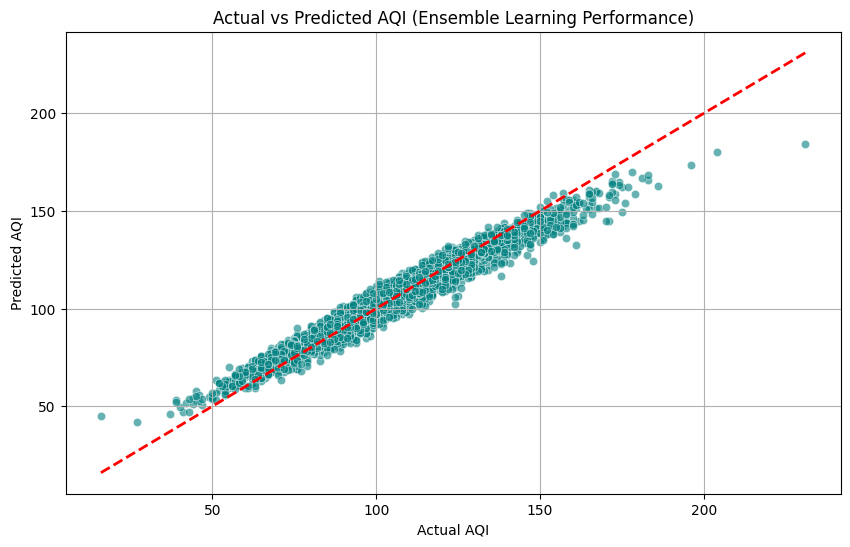

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure you use the predictions from the ensemble_model
y_pred_ensemble = ensemble_model.predict(X_test)

plt.figure(figsize=(10, 6))
# Using the ensemble predictions for the y-axis
sns.scatterplot(x=y_test, y=y_pred_ensemble, alpha=0.6, color='teal')

# Perfect prediction reference line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2)

plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.title('Actual vs Predicted AQI (Ensemble Learning Performance)')
plt.grid(True)
plt.show()

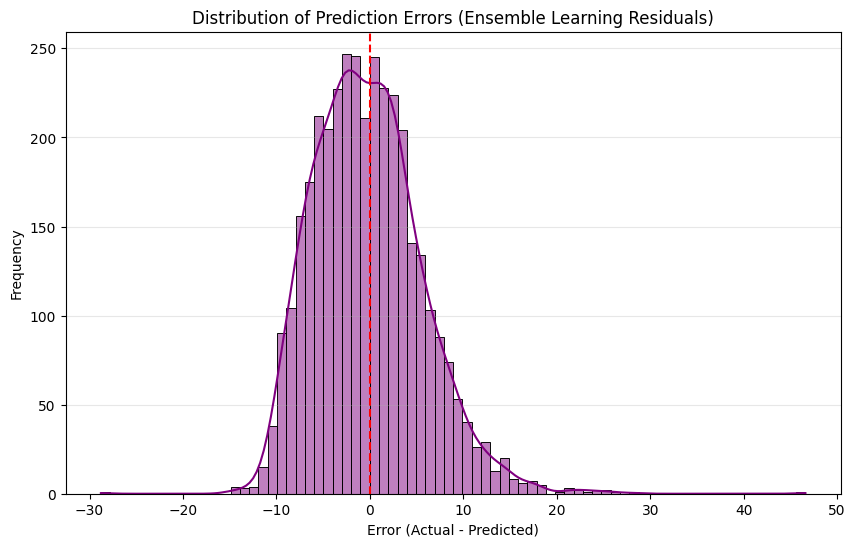

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate predictions using the ensemble model
y_pred_ensemble = ensemble_model.predict(X_test)

# Calculate residuals (errors)
residuals = y_test - y_pred_ensemble

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='purple')

plt.title('Distribution of Prediction Errors (Ensemble Learning Residuals)')
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Frequency')

# Zero line to show where predictions are perfectly accurate
plt.axvline(0, color='red', linestyle='--')
plt.grid(axis='y', alpha=0.3)
plt.show()

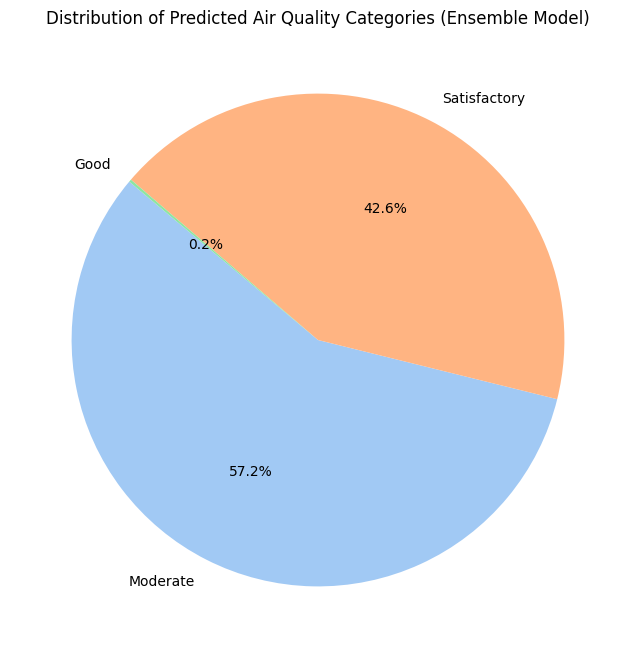

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate predictions using the ensemble model
y_pred_ensemble = ensemble_model.predict(X_test)

# Convert predicted numbers into category labels using your function
# We use pd.Series so we can use .value_counts()
predicted_categories = pd.Series(y_pred_ensemble).apply(aqi_category)

plt.figure(figsize=(8, 8))
# Use the value counts of the PREDICTED categories
predicted_categories.value_counts().plot.pie(autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))

plt.title('Distribution of Predicted Air Quality Categories (Ensemble Model)')
plt.ylabel('')
plt.show()

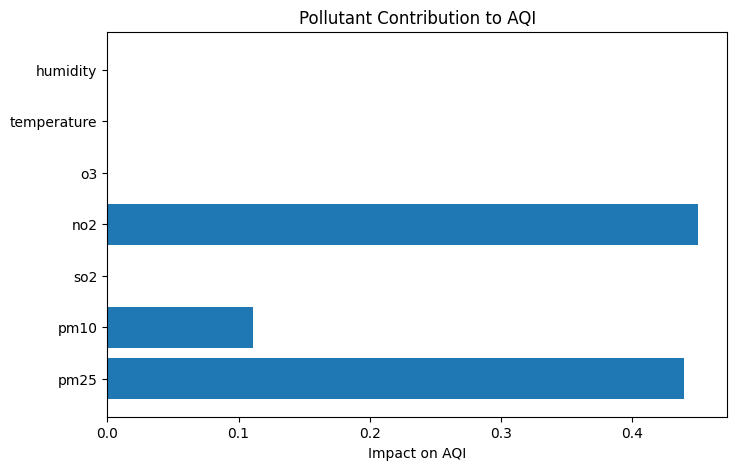

In [81]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
plt.barh(features, importance)
plt.xlabel("Impact on AQI")
plt.title("Pollutant Contribution to AQI")
plt.show()


/tmp/ipython-input-3265078051.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


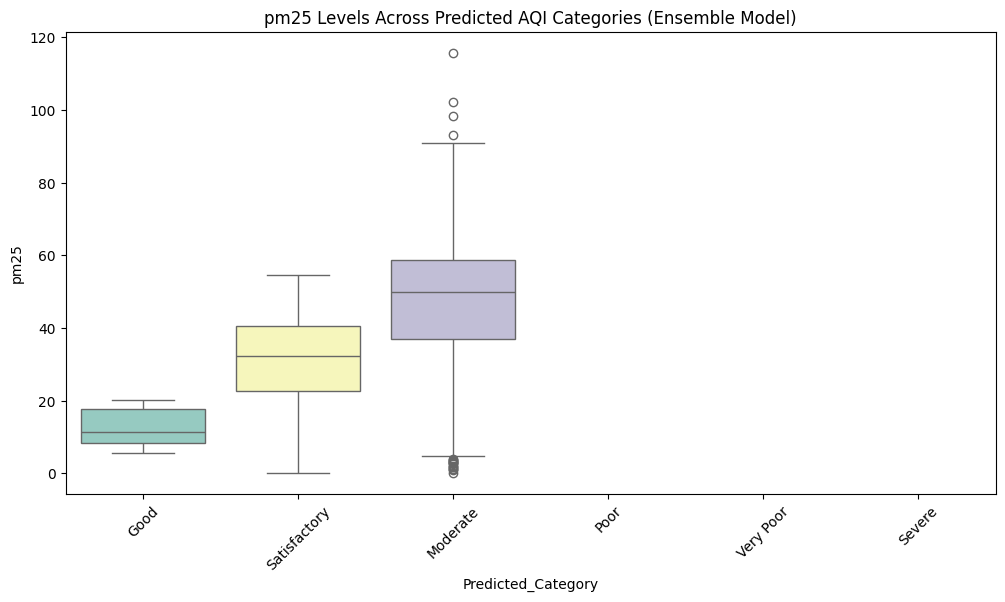

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate predictions
y_pred_ensemble = ensemble_model.predict(X_test)

# 2. Align predictions with X_test index
predicted_series = pd.Series(y_pred_ensemble, index=X_test.index)
temp_df = X_test.copy()
temp_df['Predicted_Category'] = predicted_series.apply(aqi_category)

pm25_col = [c for c in temp_df.columns if 'pm2' in c.lower()][0]

plt.figure(figsize=(12, 6))
sns.boxplot(
    x='Predicted_Category',
    y=pm25_col,
    data=temp_df,
    palette='Set3',
    order=['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
)

plt.title(f'{pm25_col} Levels Across Predicted AQI Categories (Ensemble Model)')
plt.xticks(rotation=45)
plt.show()

/tmp/ipython-input-4230726243.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


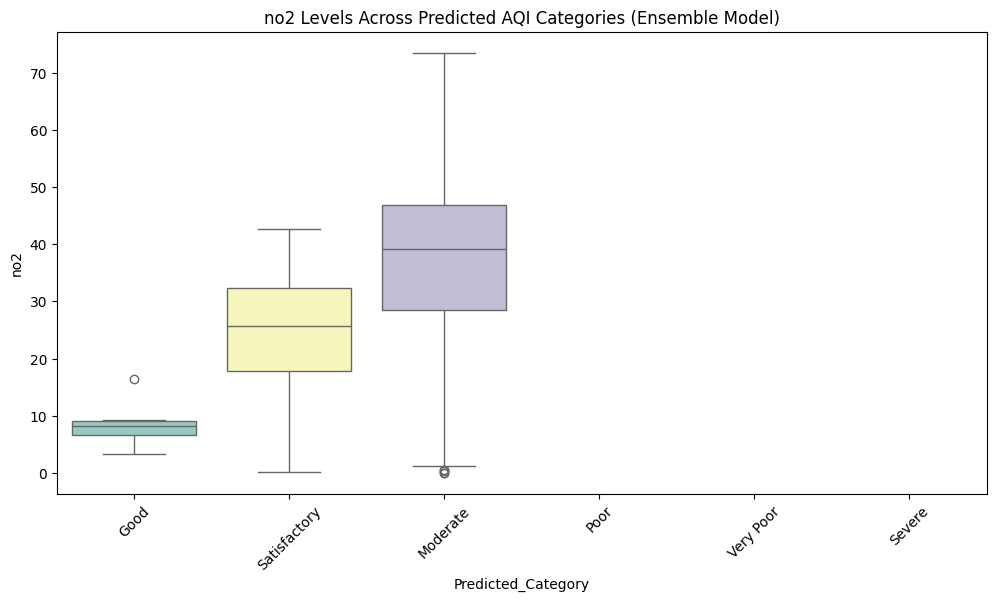

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate ensemble predictions
y_pred_ensemble = ensemble_model.predict(X_test)

# 2. Align predictions with X_test index to prevent NaN errors
predicted_series = pd.Series(y_pred_ensemble, index=X_test.index)
temp_df = X_test.copy()
temp_df['Predicted_Category'] = predicted_series.apply(aqi_category)

# 3. Dynamic Column Detection (searching for NO2 specifically)
no2_col = [c for c in temp_df.columns if 'no2' in c.lower()][0]

plt.figure(figsize=(12, 6))
# 4. Use the correct variable 'no2_col' here
sns.boxplot(
    x='Predicted_Category',
    y=no2_col,
    data=temp_df,
    palette='Set3',
    order=['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
)

plt.title(f'{no2_col} Levels Across Predicted AQI Categories (Ensemble Model)')
plt.xticks(rotation=45)
plt.show()

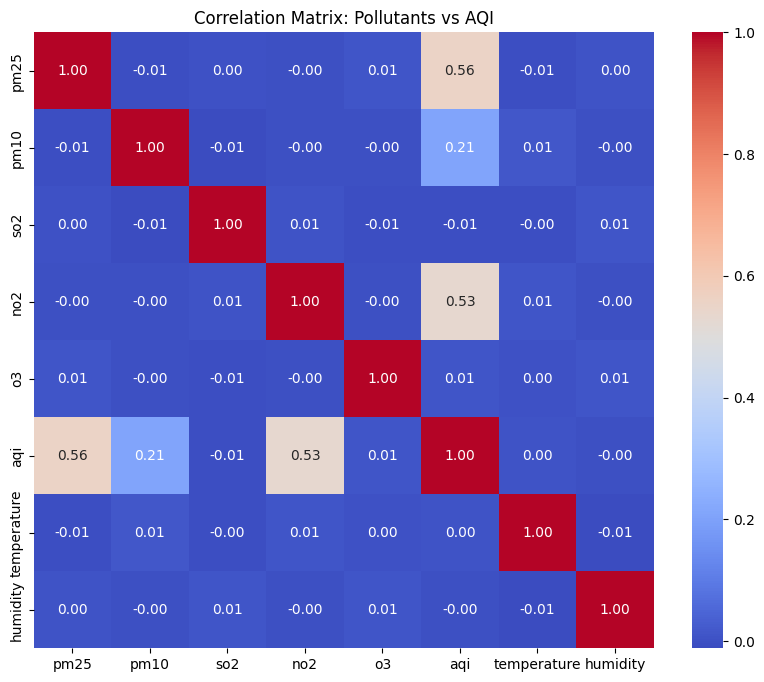

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the columns you want to look for (in lowercase)
target_cols = ['pm25', 'pm10', 'no2', 'so2', 'o3', 'co', 'aqi', 'temperature', 'humidity']
existing_cols = [c for c in df.columns if c.lower() in target_cols]

pollutants_corr = df[existing_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(pollutants_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Pollutants vs AQI")
plt.show()